In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from astropy.io import fits
from scipy.integrate import simps
from astropy.table import Table
from scipy.optimize import curve_fit
from scipy.special import erf
#from matplotlib import rc
#rc('font',**{'family':'serif','serif':['Palatino']})
#rc('text', usetex=True)

In [2]:
def one_gaussian(x,x0,sigma,Amp):
    return Amp * np.exp(-(x-x0)**2/(2*sigma**2)) 
N=3
def multiple_gaussian(x,*popt):   #Here popt must have a length of 3N+1, where N is the number of components being fit. The last element is y0
		length = len(popt) 

		#Beginning the total gaussian sum
		total_gaussian = 0
		for i in range(int(N)):
			#There are three separate parameters to fit for each gaussian: a center, fwhm, and amplitude. 
			index0 = 3 * i
			#The individual gaussian 
			gauss = one_gaussian(x,popt[index0],popt[index0+1],popt[index0+2])
			#Adding the individual Gaussian to the total gaussian
			total_gaussian += gauss


		#Adding y offset
		#total_gaussian += popt[-1]

		return total_gaussian
def individual_gaussians(x,popt,extract_popt=False):

		#This function extracts individual gaussians from the popt vector from a multi-Gaussian fit.

		num_components = N
		gauss_list = []
		popt_list = []
		for i in range(num_components):
			index0 = 3 * i
			gauss = one_gaussian(x,popt[index0],popt[index0+1],popt[index0+2])
			gauss_list.append(gauss)

			popt_list.append([popt[index0],popt[index0+1],popt[index0+2]])

		

		if extract_popt:
			return popt_list
		else:
			return gauss_list
def integral_gaussian(x,a,b,*pars):


		#I am extracting out the integral of a gaussian over a finite range x in [a,b]

		x0,sigma,Amp = pars

		integral_multiplier = np.sqrt(np.pi) * Amp * sigma/(np.sqrt(2)) #This is the amplitude of the integral of a gaussian of the form Aexp(-(x-x0)^2/(2sigma^2))



		erf_stuff = erf((b-x0)/(sigma*np.sqrt(2))) - erf((a-x0)/(sigma*np.sqrt(2))) #Here I am taking the limits based on the Fundamental Theorem of Calculus

		integral = integral_multiplier * erf_stuff  # The final form, which includes the integral of the y offset, which is simply y0 * x over the range [a,b]
		return integral

    
def mask_range(arr,a,b,other_arrays=None):  #Mask an array from value a to b
    if a > b:
        a,b = b,a
    
    masked_arr = arr[(arr >= a) & (arr <= b)]
    if not other_arrays:
        return masked_arr
    if other_arrays:
        masked_arrays = []
        for ay in other_arrays:
            masked = ay[(arr >= a) & (arr <= b)]
        return masked_arr,masked
            

        
def BPT_NII_HII(x):
    return 0.61/(x-0.05)+1.3
def BPT_SII_HII(x):
    return 1.3 + 0.72/(x-0.32)
def BPT_NII_Seyfert(x):
    return 0.61/(x-0.47)+1.19
def BPT_SII_Seyfert(x):
    return 1.89 * x +1.3

In [3]:
def mask_out(x,regions):   #Masking out wavelength regions
    masks = []
    for region in regions:
        reg_min,reg_max = region
        
        mask = (x >= reg_min) & (x <= reg_max)
        masks.append(mask)
    
    string_func = ''
    for i in range(len(masks)):
        string_func+='masks[%d]' % i
        if i!= len(masks)-1:
            string_func+=','
    
    exec('mask_tot = np.logical_not('+string_func+')')
    return masks

In [4]:
fname = '../Data/manga-8257-12701-LOGCUBE.fits'    #Disk galaxy
#fname = '../Data/manga-8257-12704-LOGCUBE.fits'    #Elliptical galaxy
fdat = fits.open(fname)

In [5]:
fdat[0].header['MANGAID']

'1-277290'

In [6]:
flux = fdat['FLUX'].data.T
wl = fdat['WAVE'].data
WLHA = 6562.81 #Angstrom

In [7]:
##wavelengths = {'H$\alpha$':WLHA,'H$\delta$':4101.734,\
 #              'H$\gamma$':4340.5,'H$\beta$':4861.3,'[OIII] 4958':4958.9,\
#              '[OIII] 5006':5006.9,'[NI] 5198':5198.6,'HeI 5875':5875.5,'[NII] 6548':6548.4,\
#               '[NII] 5754': 5754.6,'[OI] 6300': 6300.3,'[NII] 6548': [6548.4],\
#              '[NII] 6583': 6583.}

wavelengths = {'H$\\alpha$':[WLHA],'H$\\delta$':[4101.734],\
               'H$\\gamma$':[4340.5],'H$\\beta$':[4861.3],\
              '[OI]': [6300.3],'[OII]': [7320.0],'[OIII]': [4958.9,5006.9],\
              '[NI]': [5198.6],'[NII]': [5754.6,6548.4,6583.4],\
              '[SII]':[6716.4,6730.8],'HeI':[7065.3],'[ArIII]': [7135.8]}
hex_colors = {'H$\\alpha$':['#ff0000'],'H$\\delta$':['#7e00db'],\
               'H$\\gamma$':['#2300ff'],'H$\\beta$':['#00efff'],\
              '[OI]': ['#ff4f00'],'[OII]': ['#c40000'],'[OIII]': ['#00ffc0','#00ff87'],\
              '[NI]': ['#36ff00'],'[NII]': ['#f0ff00','#ff0000','#ff0000'],\
              '[SII]':['#ff0000','#ff0000'],'HeI':['#f20000'],'[ArIII]': ['#e60000']}

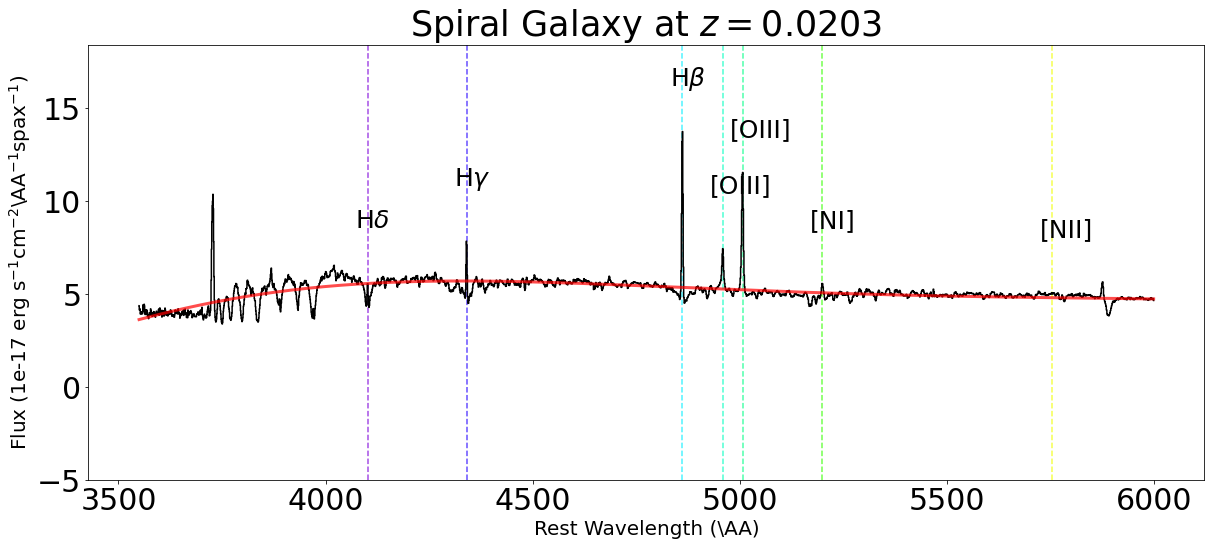

In [8]:
%matplotlib inline
plt.figure(figsize=(20,8))
i,j = 37,37
f = flux[i][j]
#plt.step(wl,f,'k-')

#Continuum fitting:

std = np.std(f)
f_mean = np.mean(f)
cont_mask = np.where((f >= f_mean - 5*std) & (f <= f_mean + 5*std))

cont_dat = f[cont_mask]
wl_cont = wl[cont_mask]

popt = np.polyfit(wl_cont,cont_dat,10)
cont_fit = np.polyval(popt,wl)
#plt.step(wl,f,'k-')
#plt.plot(wl,cont_fit,'r-',alpha=0.8)
#plt.show()
#plt.step(wl,f-cont_fit,'k-')
#mask = np.where(f==max(f))
wl_rs_Ha = wl[np.where(f==max(f))]
z = (wl_rs_Ha - WLHA)/WLHA

wl_rest = wl / (z+1)
wl_rest1 = wl_rest[(wl_rest <= 6000.)]
flux1 = (f-cont_fit)[(wl_rest <= 6000.)]
f_not_norm = f[(wl_rest <= 6000.)]
cont_masked = cont_fit[(wl_rest <= 6000.)]


plt.step(wl_rest1,f_not_norm,'k-',where='mid')
plt.plot(wl_rest1,cont_masked,'r-',alpha=0.7,linewidth=3.)
#plt.xlim(xmin=4700.,xmax=7000.)
plt.ylim(ymin=-5.,ymax=max(flux1)+10.)
#plt.vlines(x=4861.3,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=4958.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=5006.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')

for ion in wavelengths.keys():
    i = 0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wl_rest1)) and (lamb <= max(wl_rest1)):
            epsilon = 1.
            flux_val = f_not_norm[np.where(abs(wl_rest1-lamb)<=epsilon)][0]
            
            plt.vlines(x=lamb,ymin=-5.,ymax=max(flux1)+10.,linestyle='dashed',color=hex_colors[ion][i],alpha=0.7)
            exec('plt.text(lamb-30.,flux_val+3.-i,s=r\''+ion+'\',fontsize=25)')
            i+=1
#plt.plot(wl_rest[np.where(f==max(f))],max(f-cont_fit),'^')

#plt.vlines(x=WLHA,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
plt.title(r'Spiral Galaxy at $z=%.4f$' % z,fontsize=35)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
#plt.savefig('High_Energy.pdf')
plt.show()

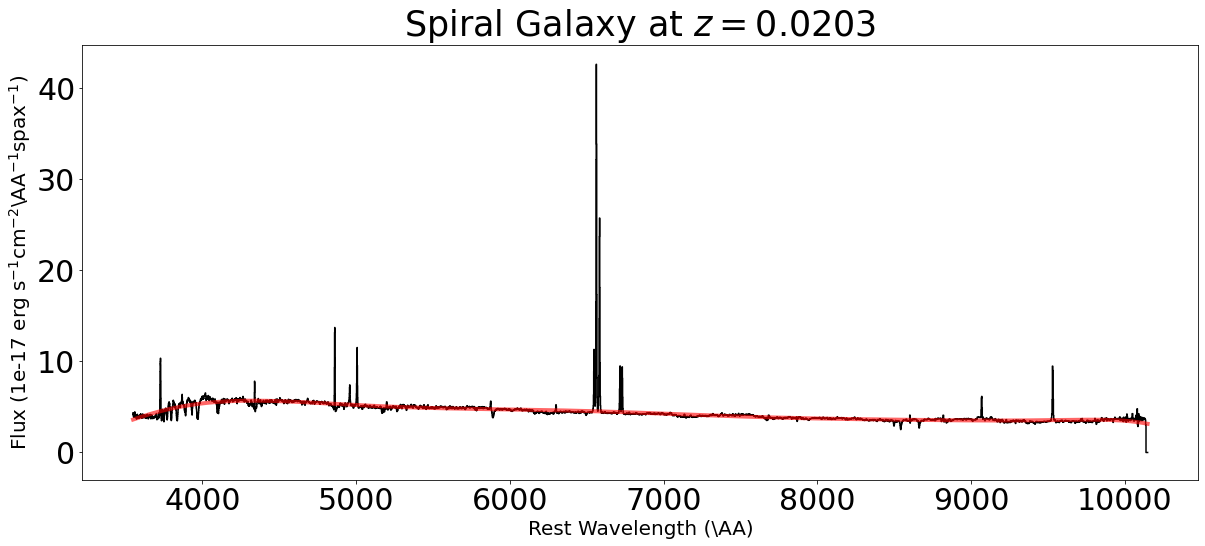

In [9]:
%matplotlib inline
plt.figure(figsize=(20,8))
i,j = 37,37
f = flux[i][j]
#plt.step(wl,f,'k-')

#Continuum fitting:

std = np.std(f)
f_mean = np.mean(f)
cont_mask = np.where((f >= f_mean - 5*std) & (f <= f_mean + 5*std))

cont_dat = f[cont_mask]
wl_cont = wl[cont_mask]

popt = np.polyfit(wl_cont,cont_dat,10)
cont_fit = np.polyval(popt,wl)
#plt.step(wl,f,'k-')
#plt.plot(wl,cont_fit,'r-',alpha=0.8)
#plt.show()
#plt.step(wl,f-cont_fit,'k-')
#mask = np.where(f==max(f))
wl_rs_Ha = wl[np.where(f==max(f))]
z = (wl_rs_Ha - WLHA)/WLHA

wl_rest = wl / (z+1)
wl_rest1 = wl_rest[(wl_rest <= 6000.)]
flux1 = (f-cont_fit)[(wl_rest <= 6000.)]



plt.step(wl_rest,f,'k-',where='mid')
plt.plot(wl_rest,cont_fit,'r-',linewidth=4.,alpha=0.6)

#plt.xlim(xmin=4700.,xmax=7000.)
plt.ylim(ymin=-3.)
#plt.vlines(x=4861.3,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=4958.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=5006.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
j = 0
#for ion in wavelengths.keys():
 #   i = 0
 #   for lamb in wavelengths[ion]:
 #       if (lamb >= min(wl_rest)) and (lamb <= max(wl_rest)):
 #           epsilon = 1.
 #           flux_val = f[np.where(abs(wl_rest-lamb)<=epsilon)][0]
            
 #           plt.vlines(x=lamb,ymin=-30.,ymax=max(flux1)+10.,linestyle='dashed',color=hex_colors[ion][i])
 #           exec('plt.text(lamb-15.,0.5-2*i-2*j,s=r\''+ion+'\',fontsize=13)')
 #           i+=1
#        j+=1
#plt.plot(wl_rest[np.where(f==max(f))],max(f-cont_fit),'^')

#plt.vlines(x=WLHA,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)
if fname == '../Data/manga-8257-12704-LOGCUBE.fits':
    
    plt.title(r'Elliptical Galaxy at $z=%.4f$' % z,fontsize=35)
    #plt.savefig('Cont_Fit_Elliptical.pdf')
elif fname == '../Data/manga-8257-12701-LOGCUBE.fits':
    plt.title(r'Spiral Galaxy at $z=%.4f$' % z,fontsize=35)
    #plt.savefig('Cont_Fit_Spiral.pdf')


plt.show()

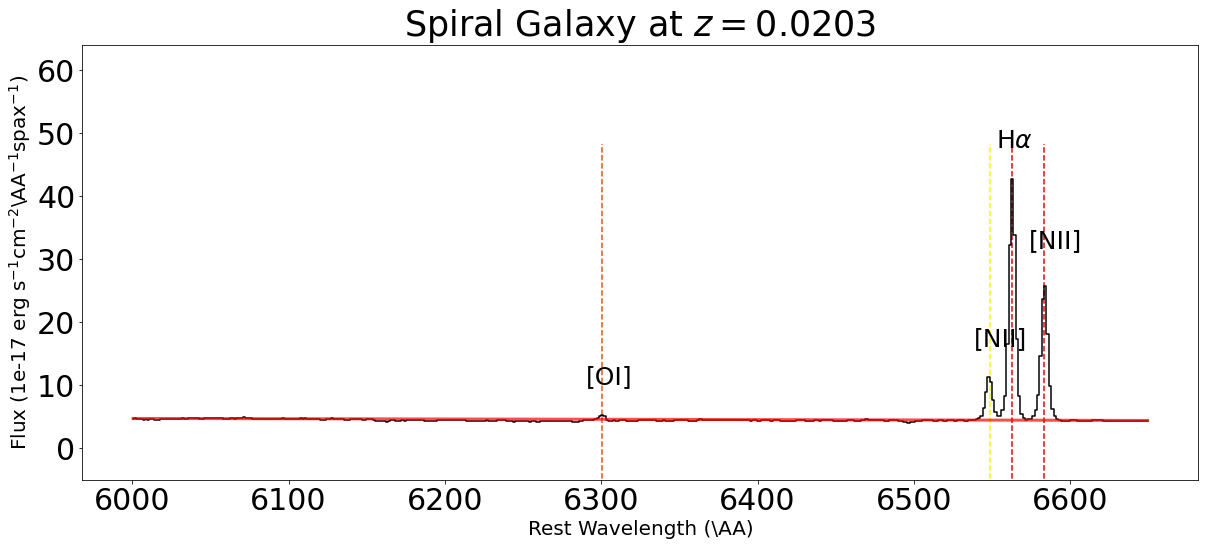

In [10]:
%matplotlib inline
plt.figure(figsize=(20,8))
i,j = 37,37
f = flux[i][j]
#plt.step(wl,f,'k-')

#Continuum fitting:

std = np.std(f)
f_mean = np.mean(f)
cont_mask = np.where((f >= f_mean - 3*std) & (f <= f_mean + 3*std))

cont_dat = f[cont_mask]
wl_cont = wl[cont_mask]

popt = np.polyfit(wl_cont,cont_dat,10)
cont_fit = np.polyval(popt,wl)
#plt.step(wl,f,'k-')
#plt.plot(wl,cont_fit,'r-',alpha=0.8)
#plt.show()
#plt.step(wl,f-cont_fit,'k-')
#mask = np.where(f==max(f))
wl_rs_Ha = wl[np.where(f==max(f))]
z = (wl_rs_Ha - WLHA)/WLHA

wl_rest = wl / (z+1)
wl_rest2 = wl_rest[(wl_rest >= 6000.) & (wl_rest <= 6650.)]
flux2 = (f-cont_fit)[(wl_rest >= 6000.) & (wl_rest <= 6650.)]

f_not_norm = f[(wl_rest >= 6000.) & (wl_rest <= 6650.)]
cont_masked = cont_fit[(wl_rest >= 6000.) & (wl_rest <= 6650.)]


plt.step(wl_rest2,f_not_norm,'k-',where='mid')
plt.plot(wl_rest2,cont_masked,'r-',alpha=0.7,linewidth=3.)

#plt.xlim(xmin=4700.,xmax=7000.)
plt.ylim(ymin=-5.,ymax=1.5*max(f_not_norm))
#plt.vlines(x=4861.3,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=4958.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=5006.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')

for ion in wavelengths.keys():
    i=0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wl_rest2)) and (lamb <= max(wl_rest2)):
            epsilon = 1.
            flux_val = f_not_norm[np.where(abs(wl_rest2-lamb)<=epsilon)][0]
            
            
            plt.vlines(x=lamb,ymin=-20.,ymax=max(flux2)+10.,linestyle='dashed',color=hex_colors[ion][i])
            exec('plt.text(lamb-10.,flux_val +5+ 3*i,s=r\''+ion+'\',fontsize=25)')
            i+=1
#plt.plot(wl_rest[np.where(f==max(f))],max(f-cont_fit),'^')

#plt.vlines(x=WLHA,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
plt.title(r'Spiral Galaxy at $z=%.4f$' % z,fontsize=35)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

#plt.savefig('MidLo_Energy.pdf')
plt.show()

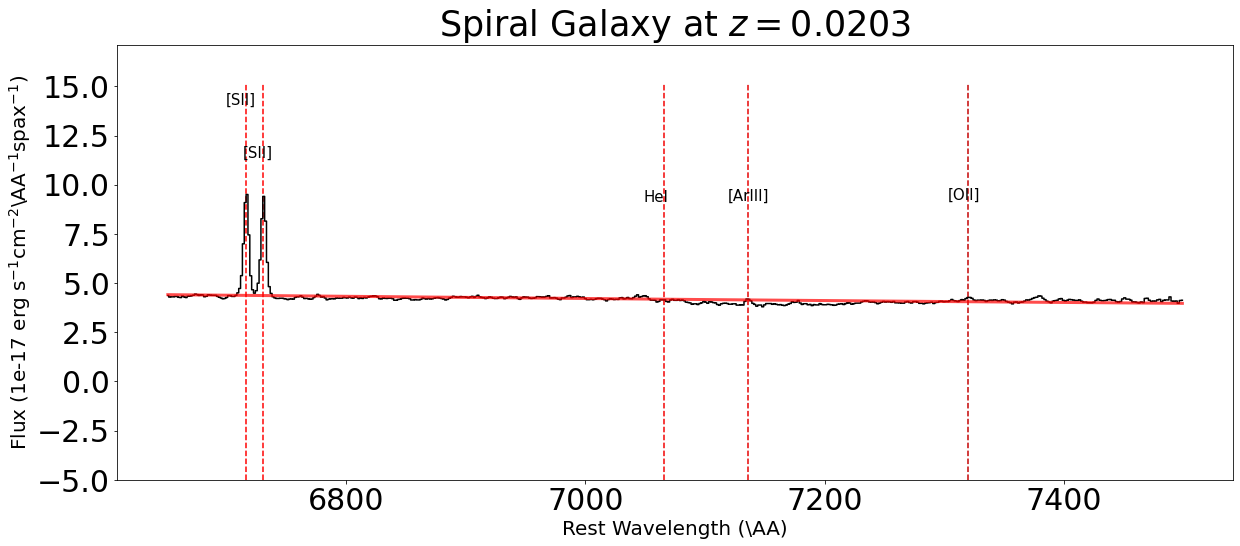

In [11]:
%matplotlib inline
plt.figure(figsize=(20,8))
i,j = 37,37
f = flux[i][j]
#plt.step(wl,f,'k-')

#Continuum fitting:

std = np.std(f)
f_mean = np.mean(f)
cont_mask = np.where((f >= f_mean - 3*std) & (f <= f_mean + 3*std))

cont_dat = f[cont_mask]
wl_cont = wl[cont_mask]

popt = np.polyfit(wl_cont,cont_dat,10)
cont_fit = np.polyval(popt,wl)
#plt.step(wl,f,'k-')
#plt.plot(wl,cont_fit,'r-',alpha=0.8)
#plt.show()
#plt.step(wl,f-cont_fit,'k-')
#mask = np.where(f==max(f))
wl_rs_Ha = wl[np.where(f==max(f))]
z = (wl_rs_Ha - WLHA)/WLHA

wl_rest = wl / (z+1)
wl_rest3 = wl_rest[(wl_rest >= 6650.) & (wl_rest <= 7500.)]
flux3 = (f-cont_fit)[(wl_rest >= 6650.)& (wl_rest <= 7500.)]

f_not_norm = f[(wl_rest >= 6650.) & (wl_rest <= 7500.)]
cont_masked = cont_fit[(wl_rest >= 6650.) & (wl_rest <= 7500.)]


plt.step(wl_rest3,f_not_norm,'k-',where='mid')
plt.plot(wl_rest3,cont_masked,'r-',alpha=0.7,linewidth=3.)

#plt.xlim(xmin=4700.,xmax=7000.)
plt.ylim(ymin=-5.,ymax=1.8*max(f_not_norm))
#plt.vlines(x=4861.3,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=4958.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
#plt.vlines(x=5006.9,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')

for ion in wavelengths.keys():
    i=0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wl_rest3)) and (lamb <= max(wl_rest3)):
            epsilon = 1.
            flux_val = f_not_norm[np.where(abs(wl_rest3-lamb)<=epsilon)][0]
            
            
            plt.vlines(x=lamb,ymin=-5.,ymax=max(flux3)+10.,linestyle='dashed',color=hex_colors[ion][i])
            exec('plt.text(lamb-17,flux_val+5 - 3*i,s=r\''+ion+'\',fontsize=15)')
            i+=1
#plt.plot(wl_rest[np.where(f==max(f))],max(f-cont_fit),'^')

#plt.vlines(x=WLHA,ymin=0,ymax=max(f-cont_fit),linestyle='dashed')
plt.title(r'Spiral Galaxy at $z=%.4f$' % z,fontsize=35)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

#plt.savefig('Lo_Energy.pdf')
plt.show()

In [12]:
#(wavelengths['HeI'][0]>= min(wl_rest)) and (wavelengths['HeI'][0]<= max(wl_rest))
(wavelengths['HeI'][0]<= max(wl_rest))

True

In [13]:
max(wl_rest)

10148.21900903066

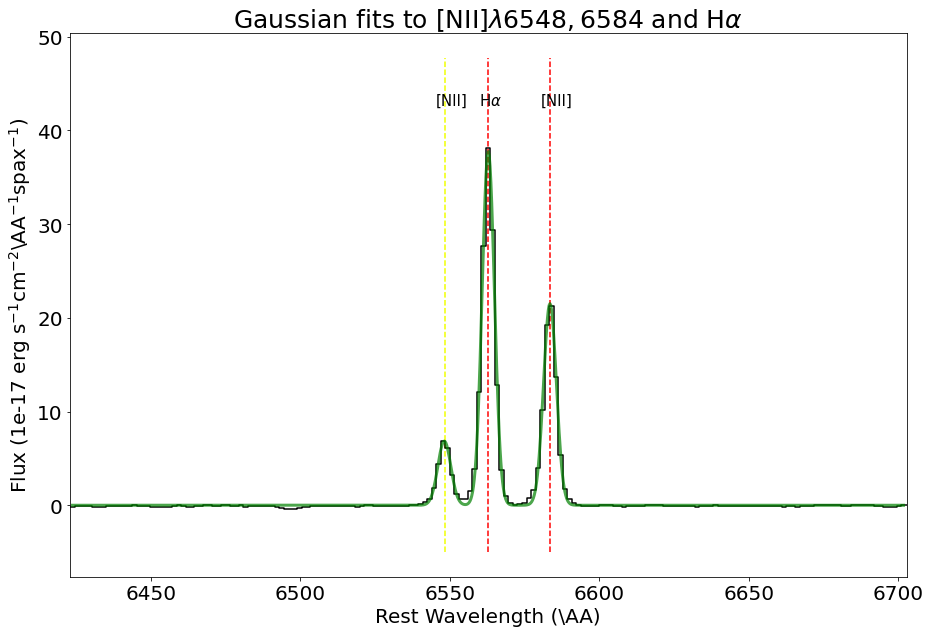

In [14]:
%matplotlib inline
plt.figure(figsize=(15,10))
maskA = (wl_rest >= WLHA-140.) & (wl_rest <= WLHA + 140.)
wl_rest_Ha = wl_rest[maskA]
flux_Ha = (f-cont_fit)[maskA]

#mask_Ha = np.logical_not(*mask_out(wl_rest_Ha,[[6538.2,6553.3],[6574.7,6593.8]]))

#wl_masked = wl_rest_Ha[mask_Ha]
#flux_masked = flux_Ha[mask_Ha]
guesses=[6547.,2.,7.,6562.,2.,40.,6583.,2.,20.]
popt_Ha,pcov = curve_fit(multiple_gaussian,wl_rest_Ha,flux_Ha,guesses)

wlr = np.linspace(wl_rest_Ha[0],wl_rest_Ha[-1],1000)
fit_Ha = multiple_gaussian(wlr,*popt_Ha)



plt.step(wl_rest,f-cont_fit,'k-',where='mid')
#plt.step(wl_masked,flux_masked,'r-')
plt.plot(wlr,fit_Ha,'g-',alpha=0.7,linewidth=3.)
plt.xlim(xmin=WLHA-140.,xmax=WLHA+140.)



for ion in wavelengths.keys():
    i=0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wlr)) and (lamb <= max(wlr)):
            epsilon = 1.
            flux_val = (f-cont_fit)[np.where(abs(wl_rest_Ha-lamb)<=epsilon)][0]
            
            
            plt.vlines(x=lamb,ymin=-5.,ymax=max(fit_Ha)+10.,linestyle='dashed',color=hex_colors[ion][i])
            exec('plt.text(lamb-3,max(fit_Ha)+5,s=r\''+ion+'\',fontsize=15)')
            i+=1

plt.title(r'Gaussian fits to [NII]$\lambda6548,6584$ and H$\alpha$',fontsize=25)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)


plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig('Ha_Gaussians.pdf')
plt.show()

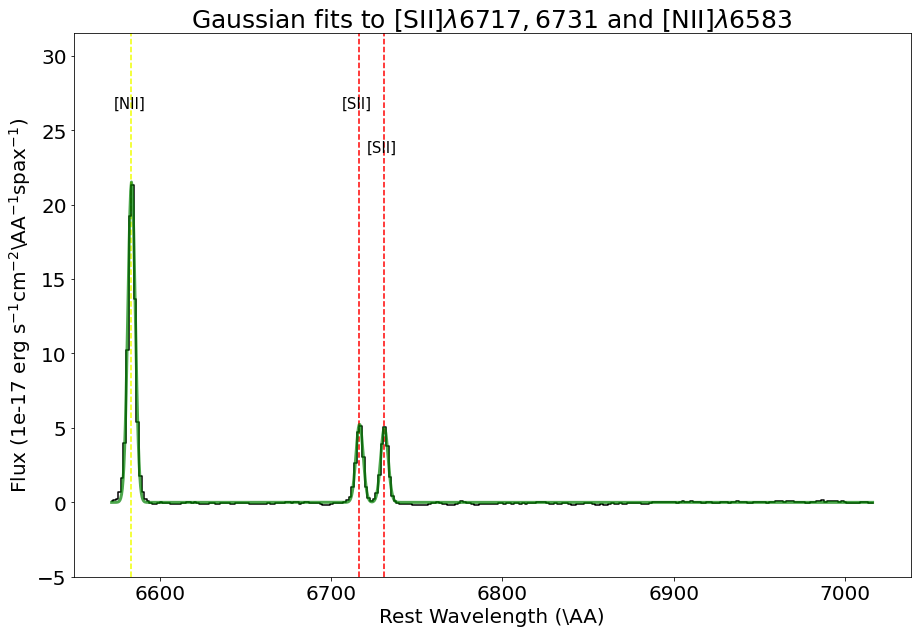

In [15]:
%matplotlib inline
plt.figure(figsize=(15,10))

WLSII_0 = wavelengths['[SII]'][0]
WLSII_1 = wavelengths['[SII]'][1]
WLSII = WLSII_0
maskSII = (wl_rest >= 6571.5) & (wl_rest <= WLSII + 300.)
wl_rest_SII = wl_rest[maskSII]
flux_SII = (f-cont_fit)[maskSII]

#mask_SII = np.logical_not(*mask_out(wl_rest_SII,[[4954.,4962.]]))

#wl_masked = wl_rest_Ha[mask_Ha]
#flux_masked = flux_Ha[mask_Ha]
guesses=[WLSII_0,2.,8.,WLSII_1,2.,2.,6572.,2.,7.]
popt_SII,pcov = curve_fit(multiple_gaussian,wl_rest_SII,flux_SII,guesses)

wlr = np.linspace(wl_rest_SII[0],wl_rest_SII[-1],1000)
fit = multiple_gaussian(wlr,*popt_SII)



plt.step(wl_rest_SII,flux_SII,'k-',where='mid')
#plt.step(wl_masked,flux_masked,'r-')
plt.plot(wlr,fit,'g-',alpha=0.7,linewidth=3.)
#plt.xlim(xmin=WLHB-140.,xmax=WLHB+140.)
plt.title(r'Gaussian fits to [SII]$\lambda6717,6731$ and [NII]$\lambda6583$',fontsize=25)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)

plt.ylim(-5.,max(fit)+10)

for ion in wavelengths.keys():
    i=0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wlr)) and (lamb <= max(wlr)):
            epsilon = 1.
            flux_val = (f-cont_fit)[np.where(abs(wl_rest_SII-lamb)<=epsilon)][0]
            
            
            plt.vlines(x=lamb,ymin=-5.,ymax=max(fit)+10.,linestyle='dashed',color=hex_colors[ion][i])
            exec('plt.text(lamb-10,max(fit)+5-3.*i,s=r\''+ion+'\',fontsize=15)')
            i+=1



plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig('SII_Gaussians.pdf')
plt.show()

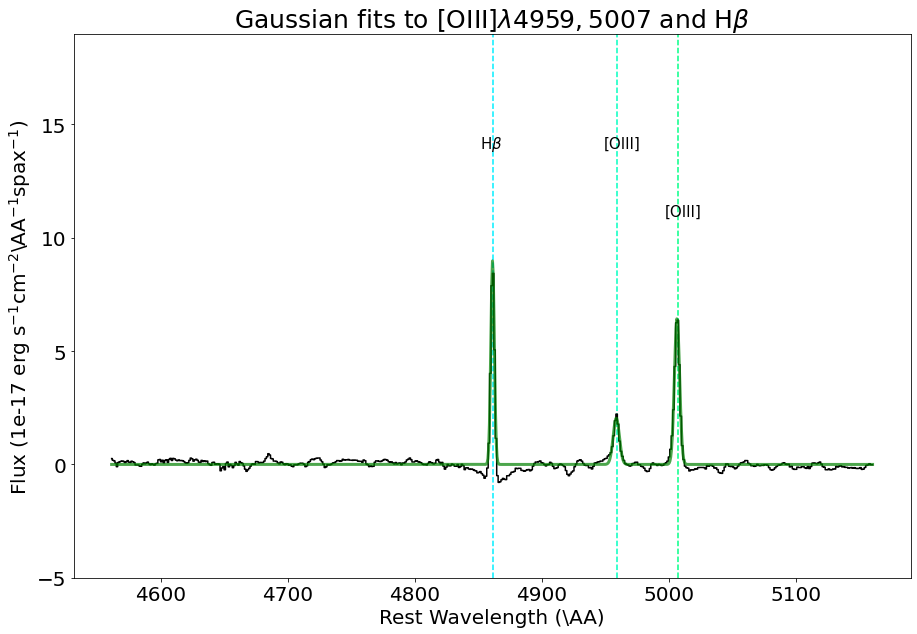

In [16]:
%matplotlib inline
plt.figure(figsize=(15,10))

WLHB = wavelengths['H$\\beta$'][0]
maskB = (wl_rest >= WLHB-300.) & (wl_rest <= WLHB + 300.)
wl_rest_Hb = wl_rest[maskB]
flux_Hb = (f-cont_fit)[maskB]

#mask_Ha = np.logical_not(*mask_out(wl_rest_Ha,[[4954.,4962.]]))

#wl_masked = wl_rest_Ha[mask_Ha]
#flux_masked = flux_Ha[mask_Ha]
guesses=[WLHB,2.,8.,4957.,2.,2.,5007.,2.,7.]
popt_Hb,pcov = curve_fit(multiple_gaussian,wl_rest_Hb,flux_Hb,guesses)

wlr = np.linspace(wl_rest_Hb[0],wl_rest_Hb[-1],1000)
fit = multiple_gaussian(wlr,*popt_Hb)

plt.title(r'Gaussian fits to [OIII]$\lambda4959,5007$ and H$\beta$',fontsize=25)
plt.xlabel(r'Rest Wavelength (\AA)',fontsize=20)
plt.ylabel(r'Flux (1e-17 erg s$^{-1}$cm$^{-2}$\AA$^{-1}$spax$^{-1}$)',fontsize=20)

plt.ylim(-5.,max(fit)+10)

for ion in wavelengths.keys():
    i=0
    for lamb in wavelengths[ion]:
        if (lamb >= min(wlr)) and (lamb <= max(wlr)):
            epsilon = 1.
            flux_val = (f-cont_fit)[np.where(abs(wl_rest_Hb-lamb)<=epsilon)][0]
            
            
            plt.vlines(x=lamb,ymin=-5.,ymax=max(fit)+10.,linestyle='dashed',color=hex_colors[ion][i])
            exec('plt.text(lamb-10,max(fit)+5-3.*i,s=r\''+ion+'\',fontsize=15)')
            i+=1


plt.step(wl_rest_Hb,flux_Hb,'k-',where='mid')
#plt.step(wl_masked,flux_masked,'r-')
plt.plot(wlr,fit,'g-',alpha=0.7,linewidth=3.)
#plt.xlim(xmin=WLHB-140.,xmax=WLHB+140.)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig('Hb_Gaussians.pdf')
plt.show()

In [17]:
popt_OIII = individual_gaussians(wl_rest,popt_Hb,extract_popt=True)[-1]
N_OIII = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_OIII)

popt_NII = individual_gaussians(wl_rest,popt_Ha,extract_popt=True)[-1]
N_NII = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_NII)

popt_SII_6717 = individual_gaussians(wl_rest,popt_SII,extract_popt=True)[0] 
popt_SII_6731 = individual_gaussians(wl_rest,popt_SII,extract_popt=True)[1]

N_SII_6717 = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_SII_6717)
N_SII_6731 = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_SII_6731)



popt_Ha_true = individual_gaussians(wl_rest,popt_Ha,extract_popt=True)[1]
popt_Hb_true = individual_gaussians(wl_rest,popt_Hb,extract_popt=True)[0]

N_Ha = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_Ha_true)
N_Hb = integral_gaussian(wl_rest,min(wl_rest),max(wl_rest),*popt_Hb_true)


In [18]:
N_SII_6731

27.081880983021207

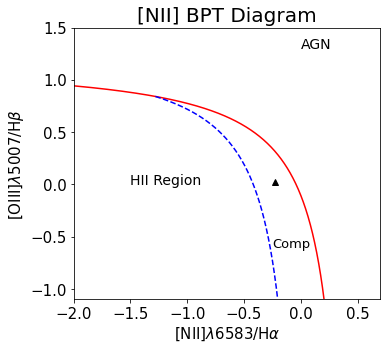

In [19]:
%matplotlib inline
plt.figure(figsize=(5.5,5))
xarr_dashed = np.linspace(-1.28,-0.1,1000)
xarr_solid = np.linspace(-2.,0.315,1000)

BPT_dashed = BPT_NII_HII(xarr_dashed)
BPT_solid = BPT_NII_Seyfert(xarr_solid)
OIII_Hb = np.log10(N_OIII/N_Hb)
NII_Ha = np.log10(N_NII/N_Ha)
plt.plot(NII_Ha,OIII_Hb,'k^')
plt.plot(xarr_solid,BPT_solid,'r-')
plt.plot(xarr_dashed,BPT_dashed,'b--')
plt.xlim(-2.,0.7)
plt.ylim(-1.1,1.5)



plt.title('[NII] BPT Diagram',fontsize=20)
plt.xlabel(r'[NII]$\lambda6583$/H$\alpha$',fontsize=15)
plt.ylabel(r'[OIII]$\lambda5007$/H$\beta$',fontsize=15)


plt.text(-1.5,0.,'HII Region',fontsize=14)
plt.text(-0.25,-0.6,'Comp',fontsize=13)
plt.text(0.0,1.3,'AGN',fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.savefig('NII_BPT.pdf')

plt.show()

<ipython-input-20-715e26d59a9a>:6: RuntimeWarning: divide by zero encountered in true_divide
  BPT_solid = 0.72 / (xarr_solid-0.32) + 1.3


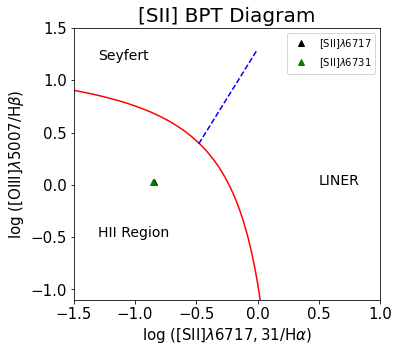

In [20]:
%matplotlib inline
plt.figure(figsize=(5.5,5))
xarr_dashed = np.linspace(-0.48,-0.01,1000)
xarr_solid = np.linspace(-2.,0.32,1000)

BPT_solid = 0.72 / (xarr_solid-0.32) + 1.3
BPT_dashed = 1.89 * xarr_dashed + 1.30
OIII_Hb = np.log10(N_OIII/N_Hb)
SII_6717_Ha = np.log10(N_SII_6717/N_Ha)
SII_6731_Ha = np.log10(N_SII_6731/N_Ha)

plt.plot(SII_6717_Ha,OIII_Hb,'k^',label=r'[SII]$\lambda6717$')
plt.plot(SII_6731_Ha,OIII_Hb,'g^',label=r'[SII]$\lambda 6731$')
plt.plot(xarr_solid,BPT_solid,'r-')
plt.plot(xarr_dashed,BPT_dashed,'b--')

plt.title('[SII] BPT Diagram',fontsize=20)
plt.xlabel(r'log ([SII]$\lambda6717,31$/H$\alpha$)',fontsize=15)
plt.ylabel(r'log ([OIII]$\lambda5007$/H$\beta$)',fontsize=15)



plt.text(-1.3,-0.5,'HII Region',fontsize=14)
plt.text(-1.3,1.2,'Seyfert',fontsize=14)
plt.text(0.5,0.0,'LINER',fontsize=14)

plt.xlim(-1.5,1.)
plt.ylim(-1.1,1.5)

plt.legend()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.savefig('SII_BPT.pdf')
plt.show()

In [21]:
plt.plot(xarr,BPT_NII_HII(xarr))
plt.show()

NameError: name 'xarr' is not defined

In [ ]:
HA_master = []
HB_master = []
OIII_master = []
NII_master = []
SII6717_master = []
SII6731_master = []
Ha = []
Hb = []
OIII = []
NII = []
SII6717 = []
SII6731 = []

zs = []

for i in range(27,46):
    
    
    for j in range(27,46):
        f = flux[i][j]
        
        sigma = np.std(f)
        mean = np.mean(f)
        
        wl_rs_Ha = wl[np.where(f==max(f))]
        z = (wl_rs_Ha - WLHA)/WLHA
        zs.append(z)

        wl_rest = wl / (z+1)
        
        
        
        cont_mask = [(f >= mean - 5*sigma) & (f <= mean + 5*sigma)]
        
        continuum = f[cont_mask]
        wl_continuum = wl_rest[cont_mask]
        
        cont_popt = np.polyfit(wl_continuum,continuum,7)
        cont_fit = np.polyval(cont_popt,wl_rest)
        
        reg_flux = f - cont_fit
        
        wl_Ha,flux_Ha = mask_range(wl_rest,WLHA-8.,WLHA+8.,[reg_flux])
        Ha_flux = simps(flux_Ha,wl_Ha)
        #Ha.append(Ha_flux)
        
        WLHB = wavelengths['H$\\beta$'][0]
        
        wl_Hb,flux_Hb = mask_range(wl_rest,WLHB-8.,WLHB+8.,[reg_flux])
        Hb_flux = simps(flux_Hb,wl_Hb)
        #Hb.append(Hb_flux)
        
        
        WLOIII = wavelengths['[OIII]'][1]
        wl_OIII,flux_OIII = mask_range(wl_rest,WLOIII-8.,WLOIII+8.,[reg_flux])
        OIII_flux = simps(flux_OIII,wl_OIII)
        #OIII.append(OIII_flux)
        
        WLNII = wavelengths['[NII]'][-1]
        wl_NII,flux_NII = mask_range(wl_rest,WLNII-8.,WLNII+8.,[reg_flux])
        NII_flux = simps(flux_NII,wl_NII)
        #NII.append(NII_flux)
        
        WLSII6717 = wavelengths['[SII]'][0]
        wl_SII6717,flux_SII6717 = mask_range(wl_rest,WLSII6717-8.,WLSII6717+8.,[reg_flux])
        SII6717_flux = simps(flux_SII6717,wl_SII6717)
        #SII6717.append(SII6717_flux)
        
        WLSII6731 = wavelengths['[SII]'][1]
        wl_SII6731,flux_SII6731 = mask_range(wl_rest,WLSII6731-8.,WLSII6731+8.,[reg_flux])
        SII6731_flux = simps(flux_SII6731,wl_SII6731)
        
        if Hb_flux > 0 and OIII_flux >0 and SII6717_flux > 0 and SII6731_flux >0:
            SII6731.append(SII6731_flux)
            SII6717.append(SII6717_flux)
            NII.append(NII_flux)
            OIII.append(OIII_flux)
            Hb.append(Hb_flux)
            Ha.append(Ha_flux)

        
        

In [ ]:
HA = np.array(Ha)
HB = np.array(Hb)
z = np.array(zs)
OIII = np.array(OIII)
NII = np.array(NII)
SII_6717 = np.array(SII6717)
SII_6731 = np.array(SII6731)

In [24]:
print('F Halpha = %.3f erg s-1 cm-2 spax-1' % N_Ha)
print('F Hbeta = %.3f erg s-1 cm-2 spax-1' % N_Hb)
print('F NII = %.3f erg s-1 cm-2 spax-1' % N_NII)
print('F OIII = %.3f erg s-1 cm-2 spax-1' % N_OIII)
print('F SII 6717 = %.3f erg s-1 cm-2 spax-1' % N_SII_6717)
print('F SII 6731 = %.3f erg s-1 cm-2 spax-1' % N_SII_6731)


F Halpha = 194.118 erg s-1 cm-2 spax-1
F Hbeta = 31.085 erg s-1 cm-2 spax-1
F NII = 115.984 erg s-1 cm-2 spax-1
F OIII = 32.961 erg s-1 cm-2 spax-1
F SII 6717 = 27.924 erg s-1 cm-2 spax-1
F SII 6731 = 27.082 erg s-1 cm-2 spax-1


In [27]:
popt_SII

array([6.71658755e+03, 2.12117616e+00, 5.25189173e+00, 6.73109889e+03,
       2.16160889e+00, 4.99817862e+00, 6.58350570e+03, 2.14961466e+00,
       2.15252046e+01])

In [ ]:
z

In [ ]:
OIII_Hb = np.divide(OIII,HB)
NII_Ha = np.divide(NII,Ha)
SII6717_Ha = np.divide(SII_6717,Ha)
SII6731_Ha = np.divide(SII_6731,Ha)

In [ ]:
OIII_Hb = np.log10(OIII_Hb)
NII_Ha = np.log10(NII_Ha)
SII6717_Ha = np.log10(SII6717_Ha)
SII6731_Ha = np.log10(SII_6731)

SII_Ha = np.log10(10**SII6731_Ha+10**SII6731_Ha)

In [ ]:
plt.plot(NII_Ha,OIII_Hb,'bo',alpha=0.2,color='k')
plt.xlabel(r'[NII]$\lambda6548$/H$\alpha$')
plt.ylabel(r'[OIII]/H$\beta$')
plt.xlim(xmin=-2.,xmax=0.7)
plt.show()

In [ ]:
plt.plot(SII_Ha,OIII_Hb,'bo',alpha=0.2)
plt.xlabel(r'[SII]$\lambda6717,31$/H$\alpha$')
plt.ylabel(r'[OIII]$\lambda5007$/H$\beta$')
plt.show()

In [ ]:
len(wl)